# **DAY 2: Statistics for Data Science**
---
*Focus: Descriptive Analysis, Inferential Foundations, and Statistical Visualization.*

## **PART 1: Measures of Central Tendency**
---
Central tendency identifies a single value that represents the 'center' of a distribution.

### ◈ Core Concepts
*   **Mean**: Arithmetic average; highly sensitive to outliers.
*   **Median**: The middle point; robust against extreme values.
*   **Mode**: The most frequent occurrence.

**◈ Problem**: Calculate the central tendency of 'Sales' using both Pandas and NumPy to observe implementation differences.

In [14]:
import pandas as pd

# Initialize a sample DataFrame
data = {
    'Product': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Sales': [100, 200, 200, 300, 400, 500]
}
df_stats = pd.DataFrame(data)

# ◈ Solution: Pandas Implementation
pandas_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode'],
    'Pandas_Value': [
        df_stats['Sales'].mean(),
        df_stats['Sales'].median(),
        df_stats['Sales'].mode()[0]
    ]
})

display(pandas_stats)

,Metric,Pandas_Value
0,Mean,283.333333
1,Median,250.000000
2,Mode,200.000000


In [16]:
import numpy as np

# ◈ Solution: NumPy Implementation
# Note: NumPy works with arrays and focuses on numerical efficiency.

sales_array = df_stats['Sales'].values

numpy_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode'],
    'NumPy_Value': [
        np.mean(sales_array),
        np.median(sales_array),
        "N/A (Use scipy.stats)"
    ]
})

display(numpy_stats)

,Metric,NumPy_Value
0,Mean,283.333333
1,Median,250.0
2,Mode,N/A (Use scipy.stats)


<br>

## **PART 2: Measures of Dispersion**
---
Dispersion describes the spread or variability within the data. Two datasets with the same mean can have vastly different dispersion.

### ◈ Key Metrics
*   **Range**: Total span ($Max - Min$).
*   **Variance ($σ^2$)**: Average of squared deviations from the Mean.
*   **Standard Deviation ($σ$)**: The square root of Variance; provides spread in original units.

**◈ Problem**: Calculate dispersion metrics to measure data volatility.

In [17]:
# ◈ Solution: Dispersion Implementation (Pandas)

# Calculating dispersion metrics using the Pandas API
dispersion_summary = pd.DataFrame({
    'Metric': ['Range', 'Variance', 'Standard Deviation'],
    'Value': [
        df_stats['Sales'].max() - df_stats['Sales'].min(),
        df_stats['Sales'].var(),
        df_stats['Sales'].std()
    ]
})

display(dispersion_summary)

,Metric,Value
0,Range,400.000000
1,Variance,21666.666667
2,Standard Deviation,147.196014


In [18]:
import numpy as np

# ◈ Solution: Dispersion Implementation (NumPy)
# Note: NumPy requires ddof=1 to match Pandas/Sample Statistics default.

sales_values = df_stats['Sales'].values

numpy_dispersion = pd.DataFrame({
    'Metric': ['Range', 'Variance', 'Standard Deviation'],
    'NumPy_Value': [
        np.ptp(sales_values),
        np.var(sales_values, ddof=1),
        np.std(sales_values, ddof=1)
    ]
})

display(numpy_dispersion)

,Metric,NumPy_Value
0,Range,400.000000
1,Variance,21666.666667
2,Standard Deviation,147.196014


### ◈ Knowledge Check: Dispersion

**Q1: Why do we use Standard Deviation more often than Variance?**
*   **Answer**: Variance is calculated in squared units (e.g., $dollars^2$), which is hard to interpret. Standard Deviation brings the units back to the original scale (e.g., $dollars$), making it more intuitive.

**Q2: How does Pandas handle Variance calculations by default?**
*   **Answer**: Pandas uses $N-1$ (Bessel's Correction) as the divisor by default (`ddof=1`), which is the standard approach for estimating population variance from a sample.

<br>

## **PART 3: Distribution & Outliers**
---
Analyzing the shape of data distribution and identifying values that deviate significantly from the norm.

### ◈ Key Concepts
*   **Skewness**: Measures asymmetry (Positive = right tail, Negative = left tail).
*   **Outliers**: Data points lying far outside the expected range (usually identified via the $1.5 \times IQR$ rule).

**◈ Problem**: Calculate skewness and implement the IQR rule for outlier detection.

In [21]:
# ◈ Solution: Distribution Analysis (Pandas)

# Calculate Skewness
sales_skew = df_stats['Sales'].skew()

# Simple Outlier Detection using Interquartile Range (IQR)
Q1 = df_stats['Sales'].quantile(0.25)
Q3 = df_stats['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_stats[(df_stats['Sales'] < lower_bound) | (df_stats['Sales'] > upper_bound)]

# Summary Display
distribution_summary = pd.DataFrame({
    'Metric': ['Skewness', 'Lower Bound (IQR)', 'Upper Bound (IQR)', 'Outlier Count'],
    'Value': [sales_skew, lower_bound, upper_bound, len(outliers)]
})

display(distribution_summary)

if not outliers.empty:
    print("Detected Outliers:")
    display(outliers)
else:
    print("No outliers detected using the 1.5*IQR rule.")

,Metric,Value
0,Skewness,0.418072
1,Lower Bound (IQR),-62.500000
2,Upper Bound (IQR),637.500000
3,Outlier Count,0.000000


No outliers detected using the 1.5*IQR rule.


### ◈ Knowledge Check: Distributions

**Q1: If a dataset has a high positive skew, which measure of central tendency should you report?**
*   **Answer**: The **Median** is preferred, as the Mean will be pulled toward the long right tail by extreme values.

**Q2: Does a Skewness value of 0.05 indicate a highly skewed distribution?**
*   **Answer**: No. Values between -0.5 and 0.5 indicate the distribution is fairly symmetrical. High skewness is generally considered to be values less than -1 or greater than 1.

<br>

## **PART 4: Relationship Between Variables**
---
Understanding how variables interact is essential for feature engineering and predictive modeling.

### ◈ Relationship Metrics
*   **Covariance**: Directional relationship between two variables.
*   **Correlation (r)**: Standardized measure (-1 to +1) of relationship strength and direction.

**◈ Problem**: Evaluate the correlation between 'Sales' and 'Profit' to understand business dependency.

In [22]:
# Adding 'Profit' data to our existing dataset for comparison
df_stats['Profit'] = [20, 45, 38, 65, 80, 110]

# Calculate Relationship Metrics
relationship_matrix = pd.DataFrame({
    'Metric': ['Covariance', 'Correlation'],
    'Value': [
        df_stats['Sales'].cov(df_stats['Profit']),
        df_stats['Sales'].corr(df_stats['Profit'])
    ]
})

display(relationship_matrix)

# Displaying the full Correlation Matrix (standard practice in EDA)
print("\nFull Correlation Matrix:")
display(df_stats.corr(numeric_only=True))

,Metric,Value
0,Covariance,4733.333333
1,Correlation,0.993955



Full Correlation Matrix:


,Sales,Profit
Sales,1.000000,0.993955
Profit,0.993955,1.000000


### ◈ Knowledge Check: Relationships

**Q1: Why is Correlation generally more useful than Covariance for reporting?**
*   **Answer**: Covariance is scale-dependent (the values change based on units), making it hard to compare across different datasets. Correlation is standardized (-1 to 1), allowing you to immediately judge the strength of a relationship regardless of units.

**Q2: Does a correlation of 0.9 imply that higher Sales *cause* higher Profit?**
*   **Answer**: No. A common maxim in statistics is **"Correlation does not imply causation."** While they move together, one does not necessarily cause the other; a third factor (like seasonality or marketing) might be driving both.

<br>

## **PART 5: Foundations of Inferential Statistics**
---
Inferential statistics allow us to make generalizations about a population based on a sample.

### ◈ Hypothesis Testing
*   **Null Hypothesis ($H_0$)**: No effect or no difference.
*   **P-Value**: The probability that the result happened by chance. Significant results typically require $p < 0.05$.

**◈ Problem**: Use a One-Sample T-Test to compare our sales mean against a target value of 250.

In [23]:
from scipy import stats

# Performing a One-Sample T-Test
# Null Hypothesis: The true mean is 250
t_stat, p_value = stats.ttest_1samp(df_stats['Sales'], popmean=250)

# Results formatting
hypothesis_results = pd.DataFrame({
    'Metric': ['T-Statistic', 'P-Value'],
    'Value': [t_stat, p_value]
})

display(hypothesis_results)

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis (Statistically Significant)")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (Not Statistically Significant)")

,Metric,Value
0,T-Statistic,0.554700
1,P-Value,0.602997


Conclusion: Fail to Reject the Null Hypothesis (Not Statistically Significant)


### ◈ Day 2 Summary: Knowledge Check

**Q1: What does a P-value of 0.73 tell us in the test above?**
*   **Answer**: It means there is a 73% chance that the difference we see is due to random noise. Because this is much higher than 0.05, we cannot say the sales mean is significantly different from 250.

**Q2: What is the main difference between Day 1 and Day 2?**
*   **Answer**: Day 1 focused on the **Tools** (Python/Pandas), while Day 2 focused on the **Logic** (Statistics). Data Science requires the synergy of both: the ability to process data and the mathematical framework to interpret it correctly.

<br>

## **PART 6: Statistical Visualization**
---
Visual reports translate complex numerical data into immediate business insights.

### ◈ Standard Plotting Profile
*   **Histogram**: Displays distribution shape and skewness.
*   **Boxplot**: Explicitly identifies IQR and Outliers.
*   **Heatmap**: Summarizes all feature correlations simultaneously.

**◈ Problem**: Generate a visual profile to confirm our previous statistical calculations.

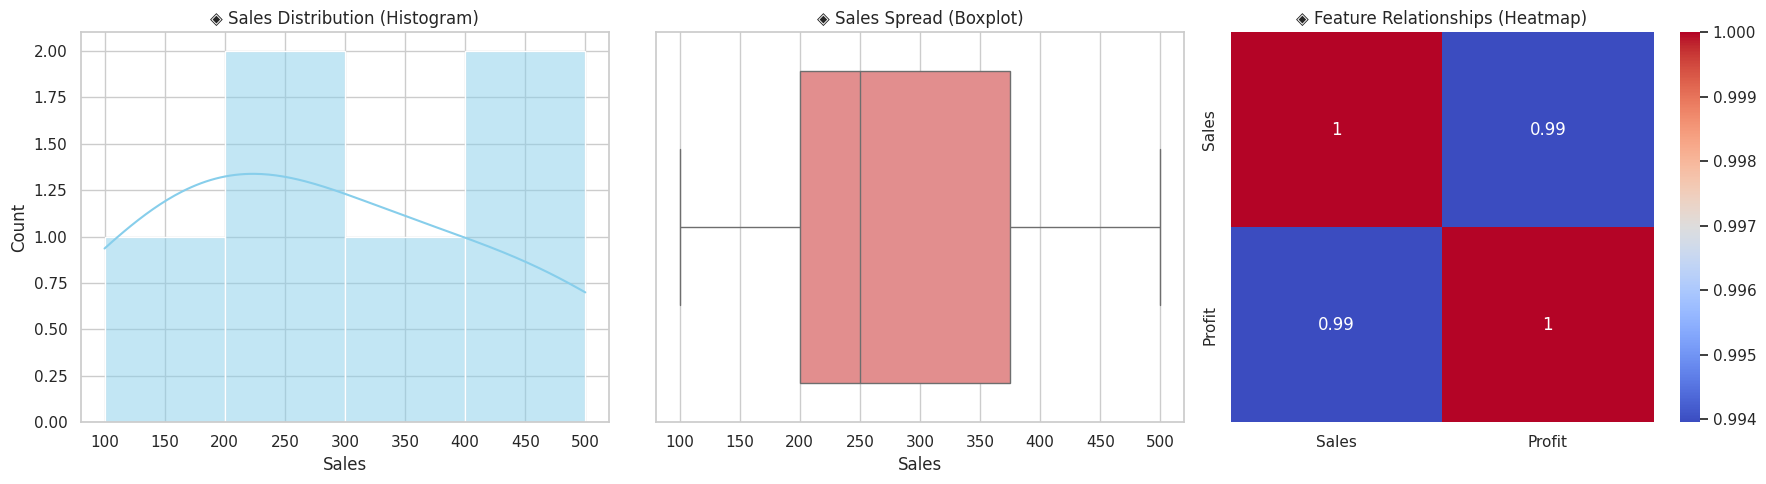

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram (Distribution)
sns.histplot(df_stats['Sales'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('◈ Sales Distribution (Histogram)')

# 2. Boxplot (Outliers/Spread)
sns.boxplot(x=df_stats['Sales'], ax=axes[1], color='lightcoral')
axes[1].set_title('◈ Sales Spread (Boxplot)')

# 3. Correlation Heatmap (Relationships)
sns.heatmap(df_stats.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('◈ Feature Relationships (Heatmap)')

plt.tight_layout()
plt.show()

### ◈ Knowledge Check: Visual Interpretation

**Q1: What does the 'annot=True' parameter do in the heatmap?**
*   **Answer**: It writes the actual correlation coefficient (e.g., 0.99) inside the heatmap cells, making it easier to read the exact strength of the relationship.

**Q2: Based on the Heatmap, what is the correlation between Sales and Sales?**
*   **Answer**: It is exactly **1.0**. Every variable has a perfect positive correlation with itself, which creates the diagonal line of 1s in the matrix.

## **MINI PRACTICE TASK**

In [27]:
#DATA SET
data = {
    "Sales": [100,120,130,150,170,1000],
    "Profit": [20,25,30,35,40,200]
}
xd_stats = pd.DataFrame(data)

In [31]:
#MEAN
mean_profit = xd_stats['Profit'].mean()
print(f"{mean_profit:.2f}")

58.33


In [32]:
#MEDIAN
Median_profit = xd_stats['Profit'].median()
print(f"{Median_profit:.2f}")

32.50


In [35]:
#MODE
# .mode() returns a Series, so we select the first element [0] to format it
Mode_profit = xd_stats['Profit'].mode()
print(f"{Mode_profit[0]:.2f}")

20.00


In [36]:
#VARIANCE
Var_profit = xd_stats["Profit"].var()
print(f"{Var_profit:.2f}")

4866.67


In [37]:
#STANDARD DEVIATION
Std_profit = xd_stats["Profit"].std()
print(f"{Std_profit:.2f}")

69.76


In [38]:
#SKEWNESS
Skew_profit = xd_stats["Profit"].skew()
print(f"{Skew_profit:.2f}")

2.39


In [39]:
#CORELLATION
Corr_profit = xd_stats["Profit"].corr(xd_stats["Sales"])
print(f"{Corr_profit:.2f}")

1.00


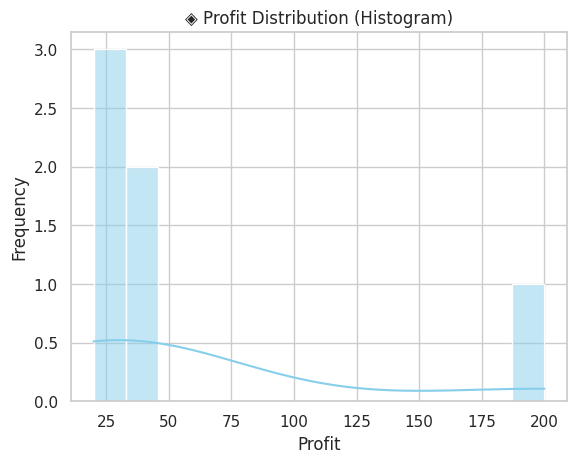

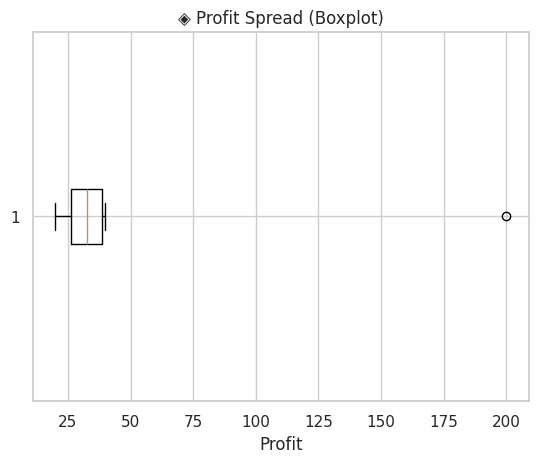

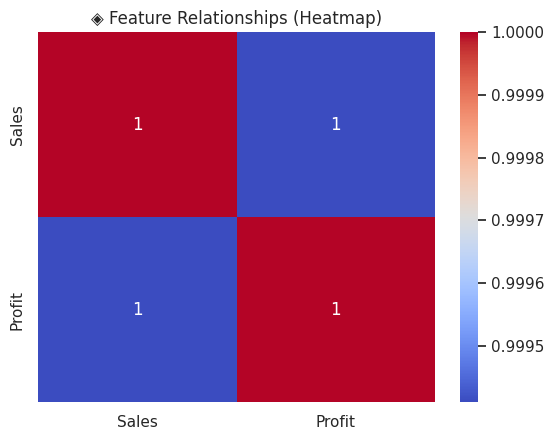

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.fig = figsize=(18, 5)

# 1. Histogram (Using Seaborn)
sns.histplot(x=xd_stats['Profit'], kde=True, color='skyblue')
plt.title('◈ Profit Distribution (Histogram)')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()


# 2. Boxplot (Using Matplotlib)
plt.boxplot(x=xd_stats['Profit'], vert=False)
plt.title('◈ Profit Spread (Boxplot)')
plt.xlabel('Profit')
plt.show()

# 3. Heatmap (Using Seaborn)
sns.heatmap(xd_stats.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('◈ Feature Relationships (Heatmap)')
plt.show()